In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return image

In [3]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    return f_transform, f_shift

In [4]:
def truncate_frequencies(f_shift, keep_fraction=0.1):
    rows, cols = f_shift.shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    r = int(min(rows, cols) * keep_fraction / 2)
    mask[crow - r:crow + r, ccol - r:ccol + r] = 1
    f_shift_truncated = f_shift * mask
    return f_shift_truncated

In [5]:
def truncate_center_coefficients(f_shift, remove_fraction=0.1):
    rows, cols = f_shift.shape
    crow, ccol = rows // 2 , cols // 2
    r = int(min(rows, cols) * remove_fraction / 2)
    mask = np.ones((rows, cols), np.uint8)
    mask[crow - r:crow + r, ccol - r:ccol + r] = 0
    f_shift_truncated = f_shift * mask
    return f_shift_truncated

In [6]:
def inverse_fourier_transform(f_shift_truncated):
    f_ishift = np.fft.ifftshift(f_shift_truncated)
    img_reconstructed = np.fft.ifft2(f_ishift)
    img_reconstructed = np.abs(img_reconstructed)
    return img_reconstructed

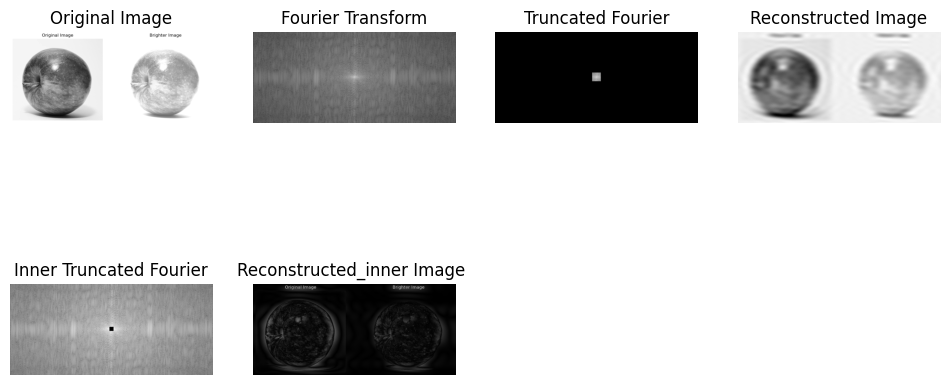

In [7]:
image_path = "red_apple.jpg" 
original = load_image(image_path)
f_transform, f_shift = apply_fourier_transform(original)
f_shift_truncated = truncate_frequencies(f_shift, keep_fraction=0.1)
reconstructed = inverse_fourier_transform(f_shift_truncated)

f_shift_inner_truncated = truncate_center_coefficients(f_shift, remove_fraction=0.05)
reconstructed_inner = inverse_fourier_transform(f_shift_inner_truncated)

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(original, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(np.log1p(np.abs(f_shift)), cmap='gray')
plt.title("Fourier Transform")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(np.log1p(np.abs(f_shift_truncated)), cmap='gray')
plt.title("Truncated Fourier")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(np.log1p(np.abs(f_shift_inner_truncated)), cmap='gray')
plt.title("Inner Truncated Fourier")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(reconstructed_inner, cmap='gray')
plt.title("Reconstructed_inner Image ")
plt.axis("off")

plt.show()